# LD50 Toxicity Prediction — Starter Notebook

**PharmaHacks 2026 ML Challenge**

---

**Your task:** Predict the acute toxicity (LD50) of drug-like molecules from their chemical structure.

**The target** (`Y`) is the log-transformed LD50 in mg/kg. Higher values = less toxic, lower values = more toxic. This is a **regression** problem.

Each molecule is given as a **SMILES string** — a text encoding of molecular structure (e.g. `CC(=O)Oc1ccccc1C(=O)O` is aspirin).

## The Dataset

We use the **LD50_Zhu** dataset from [Therapeutics Data Commons (TDC)](https://tdcommons.ai/single_pred_tasks/tox/#ld50-zhu), originally published in:

> Zhu et al., *Quantitative Structure-Activity Relationship Modeling of Rat Acute Toxicity by Oral Exposure*, Chemical Research in Toxicology (2009).

**LD50** (Lethal Dose, 50%) is the dose of a substance required to kill 50% of a test population (measured in rats, oral administration). It is one of the most fundamental measures of acute toxicity in pharmacology.

The dataset contains ~7,400 molecules. Each row has three columns:

- **Drug_ID**: a unique identifier
- **Drug**: the molecular structure as a [SMILES](https://en.wikipedia.org/wiki/Simplified_molecular-input_line-entry_system) string
- **Y**: the target: log-transformed LD50 in mg/kg (**higher = less toxic, lower = more toxic**)

**Task:** Regression: predict the continuous log(LD50) value from molecular structure.

In [107]:
# don't worry if this takes a while
# !pip install PyTDC rdkit xgboost -q
# IMPORTANT: If you are running this in google collab, after installing packages RESTART YOUR RUNTIME
# Then skip this cell and you can run the rest of the notebook (package are already installed)
# If you get ERROR: pip's dependency resolver does not currently take into account all the packages that are installed
# you can safely ignore it

In [108]:
# # 1. Mise à jour des outils d'installation (crucial sur Windows)
# !python -m pip install --upgrade pip setuptools wheel

# # 2. Installation des bibliothèques qui ne posent pas de problème
# !pip install rdkit xgboost pandas numpy scikit-learn -q

# # 3. Installation de PyTDC (on tente sans les dépendances qui bloquent)
# !pip install PyTDC --no-deps

# !pip install tqdm pandas numpy scikit-learn fuzzywuzzy huggingface_hub python-Levenshtein -q
# !pip install shap

## 2. Load the Data

In [109]:
from tdc.single_pred import Tox

data  = Tox(name='LD50_Zhu')
split = data.get_split()

train_df = split['train']
valid_df = split['valid']
test_df  = split['test']

print(f"Train: {len(train_df)}  |  Valid: {len(valid_df)}  |  Test: {len(test_df)}")
print(f"Columns: {list(train_df.columns)}")
train_df.head()

Found local copy...
Loading...
Done!


Train: 5170  |  Valid: 738  |  Test: 1477
Columns: ['Drug_ID', 'Drug', 'Y']


,Drug_ID,Drug,Y
0,"Methane, tribromo-",BrC(Br)Br,2.343
1,Bromoethene (9CI),C=CBr,2.330
2,"1,1'-Biphenyl, hexabromo-",Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465
3,"Isothiocyanic acid, p-bromophenyl ester",S=C=Nc1ccc(Br)cc1,2.729
4,"Benzene, bromo-",Brc1ccccc1,1.765


## 3. Where to Go From Here

Here's a suggested roadmap feel free to skip around or go in a completely different direction.

**Step 1: Explore the data.** Plot the distribution of the target variable. Look at summary statistics. Are there outliers? Is the distribution skewed?

**Step 2: Featurize the molecules.** SMILES strings are text and models need numbers. Convert each molecule to a numerical vector using RDKit.

You can also explore MACCS keys, physicochemical descriptors (molecular weight, logP, etc.), or atom-pair fingerprints.

**Step 3: Train a simple model.** Start with something basic like Ridge regression or Random Forest from scikit-learn. Evaluate on the validation set using R², MAE, and RMSE.

**Step 4: Improve.** Try more models (XGBoost, Gradient Boosting, etc.), tune hyperparameters, engineer better features, analyze your errors.



In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tdc.single_pred import Tox

import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit.Chem import MACCSkeys
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator

import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge

import shap
import random
import os

def set_seed(seed=42):
    """Fixe toutes les graines aléatoires pour garantir la reproductibilité des résultats."""
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Graine aléatoire fixée à {seed} : Reproductibilité garantie.")

set_seed(42)

# Configuration esthétique pour des graphiques de qualité présentation
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


Graine aléatoire fixée à 42 : Reproductibilité garantie.


In [111]:
# CELLULE 4 : Représentation Moléculaire - Morgan 

def smiles_to_morgan(smiles, radius=2, n_bits=1024):
    """
    Convertit un SMILES en Morgan Fingerprint (vecteur binaire numpy).
    """
    # TODO 1 : Convertir la chaîne 'smiles' en objet Molécule RDKit en utilisant Chem.MolFromSmiles()
    mol = Chem.MolFromSmiles(smiles)
    
    # TODO 2 : Gérer les erreurs. Si la molécule est invalide (mol est None), 
    if mol is None:
        return np.zeros(n_bits, dtype=np.int8)

    
    # TODO 3 : Générer le fingerprint avec AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits)
    mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = mfpgen.GetFingerprint(mol)

    # TODO 4 : Convertir 'fp' (qui est un objet RDKit) en tableau Numpy (utiliser DataStructs.ConvertToNumpyArray)
    arr = np.zeros(n_bits, dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    
    return arr

# TODO 5 : Appliquer cette fonction sur la colonne 'Drug' de train_df, valid_df et test_df.
# L'objectif est de créer trois nouveaux DataFrames (ou matrices Numpy) : X_train_morgan, X_valid_morgan, X_test_morgan.
X_train_morgan = pd.DataFrame([smiles_to_morgan(s) for s in train_df['Drug']])
X_valid_morgan = pd.DataFrame([smiles_to_morgan(s) for s in valid_df['Drug']])
X_test_morgan  = pd.DataFrame([smiles_to_morgan(s) for s in test_df['Drug']])

print(f"Fingerprints générés sans avertissement ! Dimension : {X_train_morgan.shape}")

Fingerprints générés sans avertissement ! Dimension : (5170, 1024)


In [112]:
# CELLULE 5 : Ingénierie des Caractéristiques Avancées (Physico-chimie & MACCS)

def get_advanced_descriptors(smiles):
    """
    Extrait les propriétés physiques et les toxicophores (MACCS) d'une molécule.
    """
    mol = Chem.MolFromSmiles(smiles)
    
    # Gestion des erreurs : si la molécule est invalide, on retourne des zéros.
    # On a 5 descripteurs physiques + 167 clés MACCS (la clé 0 est toujours vide dans RDKit).
    if mol is None:
        return [0.0]*5 + [0]*167 
    
    # TODO 1 : Extraire les 5 descripteurs physico-chimiques en utilisant le module Descriptors
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)
    
    physchem_features = [mw, logp, hbd, hba, tpsa]
    
    # TODO 2 : Générer les clés MACCS
    maccs_fp = MACCSkeys.GenMACCSKeys(mol)
    
    # TODO 3 : Convertir maccs_fp en tableau Numpy (exactement comme dans la Cellule 4)
    # Astuce : utilise np.int8 pour économiser de la mémoire !
    maccs_arr = np.zeros(167, dtype=np.int8)
    DataStructs.ConvertToNumpyArray(maccs_fp, maccs_arr)
    
    # On retourne une seule grande liste contenant les 5 valeurs physiques + les 167 zéros/uns
    return physchem_features + list(maccs_arr)

# Noms des colonnes pour le DataFrame
cols = ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA'] + [f'MACCS_{i}' for i in range(167)]

# TODO 4 : Utiliser une liste en compréhension (comme dans la Cellule 4) pour appliquer 
# get_advanced_descriptors sur train_df, valid_df et test_df.
# N'oublie pas de spécifier columns=cols lors de la création du pd.DataFrame !
X_train_adv = pd.DataFrame([get_advanced_descriptors(s) for s in train_df['Drug']], columns=cols)
X_valid_adv = pd.DataFrame([get_advanced_descriptors(s) for s in valid_df['Drug']], columns=cols)
X_test_adv = pd.DataFrame([get_advanced_descriptors(s) for s in test_df['Drug']], columns=cols)

print(f"Descripteurs avancés extraits ! Dimension : {X_train_adv.shape}")

Descripteurs avancés extraits ! Dimension : (5170, 172)


In [113]:
# CELLULE 6 : Fusion et Normalisation (StandardScaling)

# TODO 1 : Fusionner (concaténer) horizontalement les Morgan et les Adv pour chaque set.
# Utilise pd.concat([df_morgan, df_adv], axis=1) pour train, valid et test.
X_train = pd.concat([X_train_morgan, X_train_adv], axis=1)
X_valid = pd.concat([X_valid_morgan, X_valid_adv], axis=1)
X_test = pd.concat([X_test_morgan, X_test_adv], axis=1)

# Les 5 premières colonnes de la partie 'adv' sont nos descripteurs continus.
cols_to_scale = ['MolWt', 'LogP', 'HBD', 'HBA', 'TPSA']

# TODO 2 : Instancier le StandardScaler de Scikit-learn
scaler = StandardScaler()

# TODO 3 : "Apprendre" la moyenne/écart-type UNIQUEMENT sur l'ensemble d'entraînement 
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# TODO 4 : Appliquer la transformation (sans réapprendre !) sur valid et test.
X_valid[cols_to_scale] = scaler.transform(X_valid[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Préparation de nos cibles (Y) sous forme de tableaux Numpy pour l'entraînement
y_train = train_df['Y'].values
y_valid = valid_df['Y'].values
y_test = test_df['Y'].values

print(f"Données prêtes pour l'IA ! Dimension finale de X_train : {X_train.shape}")

Données prêtes pour l'IA ! Dimension finale de X_train : (5170, 1196)


[0]	validation_0-rmse:0.94628	validation_1-rmse:0.96742
[100]	validation_0-rmse:0.55078	validation_1-rmse:0.64999
[200]	validation_0-rmse:0.48534	validation_1-rmse:0.62520
[300]	validation_0-rmse:0.44382	validation_1-rmse:0.61266
[400]	validation_0-rmse:0.40984	validation_1-rmse:0.60331
[500]	validation_0-rmse:0.38331	validation_1-rmse:0.59769
[600]	validation_0-rmse:0.35958	validation_1-rmse:0.59275
[700]	validation_0-rmse:0.33853	validation_1-rmse:0.59008
[800]	validation_0-rmse:0.31939	validation_1-rmse:0.58655
[900]	validation_0-rmse:0.30174	validation_1-rmse:0.58475
[1000]	validation_0-rmse:0.28610	validation_1-rmse:0.58243
[1100]	validation_0-rmse:0.27177	validation_1-rmse:0.58044
[1200]	validation_0-rmse:0.25775	validation_1-rmse:0.57948
[1300]	validation_0-rmse:0.24601	validation_1-rmse:0.57855
[1400]	validation_0-rmse:0.23441	validation_1-rmse:0.57744
[1499]	validation_0-rmse:0.22387	validation_1-rmse:0.57653
Modèle entraîné !
Performances sur la Validation :
R2   : 0.6526
MAE

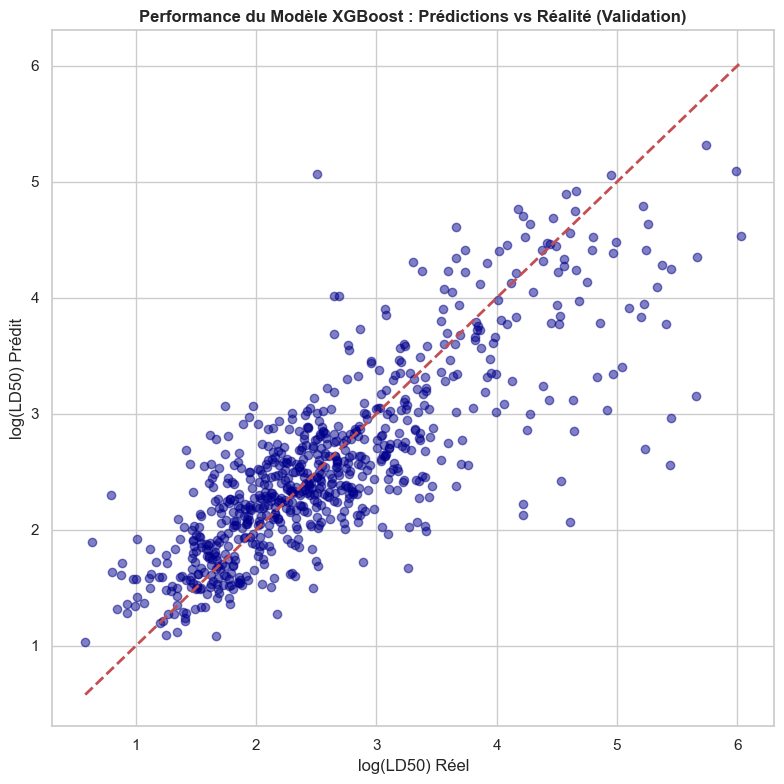

In [114]:
# CELLULE 7 : Entraînement du Modèle Principal (XGBoost)

# TODO 1 : Instancier le modèle XGBRegressor. 
# Instanciation avec des hyperparamètres agressifs pour combattre le bruit chimique
model_xgb_opt = xgb.XGBRegressor(
    n_estimators=1500,          # Beaucoup plus d'arbres
    learning_rate=0.03,         # Apprentissage plus lent et minutieux
    max_depth=7,                # Arbres un peu plus profonds pour capter les interactions complexes
    subsample=0.8,              # Utilise 80% des lignes par arbre (réduit l'overfitting)
    colsample_bytree=0.3,       # TRÈS IMPORTANT : Utilise seulement 30% des colonnes par arbre
    reg_alpha=1.0,              # Régularisation L1 (Lasso) pour "éteindre" le bruit des fingerprints
    reg_lambda=2.0,             # Régularisation L2 (Ridge) pour stabiliser les poids
    random_state=42,
    early_stopping_rounds=50    # S'arrête si pas d'amélioration sur la validation après 50 arbres
)

# TODO 2 : Entraîner le modèle sur X_train et y_train
# Convertis X_train et y_train si nécessaire, mais XGBoost accepte les DataFrames Pandas.
model_xgb_opt.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    verbose=100
)

print("Modèle entraîné !")

# TODO 3 : Faire des prédictions sur l'ensemble de VALIDATION (X_valid)
y_pred_valid_opt = model_xgb_opt.predict(X_valid)

# TODO 4 : Calculer les 3 métriques d'évaluation demandées par le jury en utilisant scikit-learn
# r2_score, mean_absolute_error, et mean_squared_error (avec squared=False pour avoir la RMSE)
r2 = r2_score(y_valid, y_pred_valid_opt)
mae = mean_absolute_error(y_valid, y_pred_valid_opt)
rmse = np.sqrt(mean_squared_error(y_valid, y_pred_valid_opt))

print(f"Performances sur la Validation :")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

# Ce code trace un graphique "Valeurs Réelles vs Prédictions" pour tes slides.
plt.figure(figsize=(8, 8))
plt.scatter(y_valid, y_pred_valid_opt, alpha=0.5, color='darkblue')
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--', lw=2)
plt.title('Performance du Modèle XGBoost : Prédictions vs Réalité (Validation)', fontweight='bold')
plt.xlabel('log(LD50) Réel', fontsize=12)
plt.ylabel('log(LD50) Prédit', fontsize=12)
plt.tight_layout()
plt.show()

Valeurs SHAP calculées ! Génération du graphique récapitulatif...


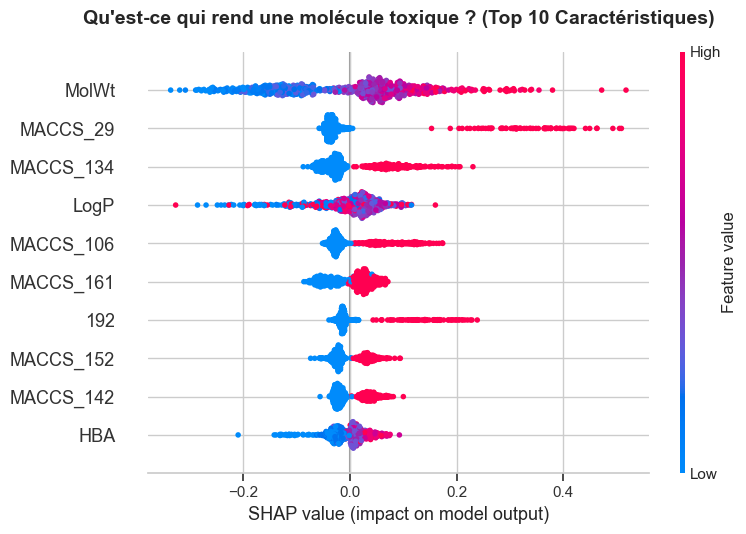

In [115]:
# CELLULE 8 : Interprétabilité et Explicabilité Médicale (SHAP)

# 1. Initialisation de l'explorateur SHAP sur notre modèle optimisé
explainer = shap.TreeExplainer(model_xgb_opt)

# 2. Calcul des valeurs SHAP sur l'ensemble de validation
# On utilise X_valid pour voir comment le modèle prend ses décisions sur des données inédites
shap_values = explainer(X_valid)

print("Valeurs SHAP calculées ! Génération du graphique récapitulatif...")

# 3. Le "Summary Plot" (Le graphique à mettre dans tes slides !)
plt.figure(figsize=(10, 8))
plt.title("Qu'est-ce qui rend une molécule toxique ? (Top 10 Caractéristiques)", fontsize=14, fontweight='bold', pad=20)

# max_display=10 pour garder le graphique lisible pour le jury
shap.summary_plot(shap_values, X_valid, max_display=10, show=False) 

plt.tight_layout()
plt.show()

 Étude de la molécule : Ethanol, 2-((1-isobutyl-3,5-dimethylhexyl)oxy)- (index 42)
  Vraie log(LD50) : 1.6330
  Prédiction IA   : 1.7508
  Erreur absolue  : 0.1178


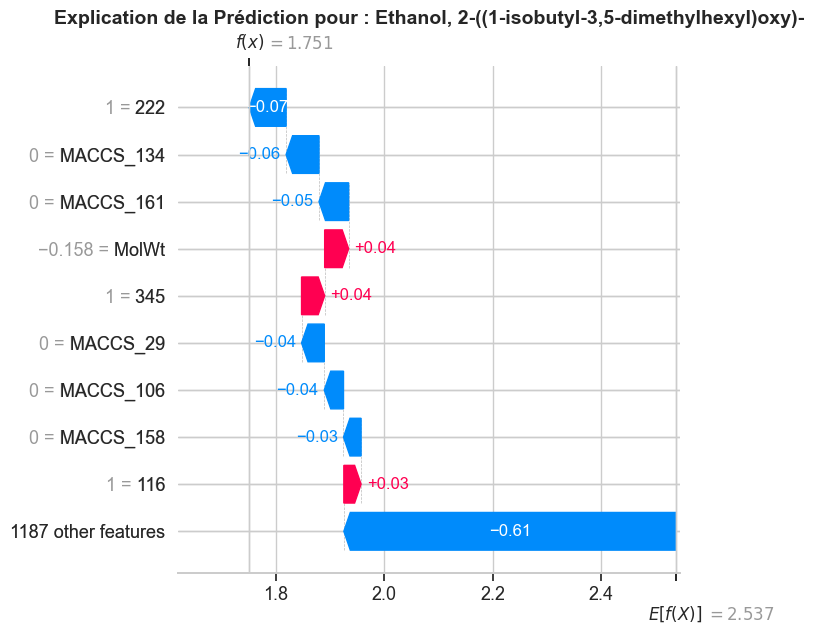

In [116]:
# CELLULE 9 : Étude de Cas (Explicabilité Individuelle avec Waterfall SHAP)

# 1. Sélection d'une molécule spécifique dans l'ensemble de validation
# Prenons la molécule à l'index 42 (un clin d'œil à la graine aléatoire)
molecule_index = 42

molecule_id = valid_df['Drug_ID'].iloc[molecule_index]

# Récupération de la molécule, de sa vraie toxicité et de sa prédiction
mol_data = X_valid.iloc[molecule_index]
true_y = y_valid[molecule_index]
pred_y = y_pred_valid_opt[molecule_index]

print(f" Étude de la molécule : {molecule_id} (index {molecule_index})")
print(f"  Vraie log(LD50) : {true_y:.4f}")
print(f"  Prédiction IA   : {pred_y:.4f}")
print(f"  Erreur absolue  : {abs(true_y - pred_y):.4f}")

# 2. Préparation des données pour le graphique Waterfall
# On doit extraire l'explication spécifique pour cette seule molécule
shap_values_single = shap_values[molecule_index]

# 3. Création du graphique en cascade
plt.figure(figsize=(10, 6))
plt.title(f"Explication de la Prédiction pour : {molecule_id}", fontsize=14, fontweight='bold')

# Le graphique montre comment chaque caractéristique pousse la prédiction
# vers le haut (moins toxique, en rouge/rose) ou vers le bas (plus toxique, en bleu)
shap.plots.waterfall(shap_values_single, max_display=10, show=False)

plt.tight_layout()
plt.show()

In [119]:
# CELLULE 10 : Évaluation Finale sur l'Ensemble de Test Caché

# 1. Prédictions finales
# On utilise notre modèle optimisé sur les données de test
y_pred_test = model_xgb_opt.predict(X_test)

# 2. Calcul des scores officiels
r2_final = r2_score(y_test, y_pred_test)
mae_final = mean_absolute_error(y_test, y_pred_test)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("\n" + "="*50)
print("SCORES OFFICIELS FINAUX (TEST SET)")
print("="*50)
print(f"R2   : {r2_final:.4f}")
print(f"MAE  : {mae_final:.4f}")
print(f"RMSE : {rmse_final:.4f}")
print("="*50)

# 3. Création du fichier de soumission (Submission CSV)
submission_df = pd.DataFrame({
    'Drug_ID': test_df['Drug_ID'],
    'Drug_SMILES': test_df['Drug'],
    'True_logLD50': y_test,
    'Predicted_logLD50': y_pred_test
})

# Sauvegarde du fichier dans le dossier du hackathon
submission_filename = "LD50_Zhu_Predictions_Finales.csv"
submission_df.to_csv(submission_filename, index=False)


SCORES OFFICIELS FINAUX (TEST SET)
R2   : 0.6705
MAE  : 0.3969
RMSE : 0.5426
